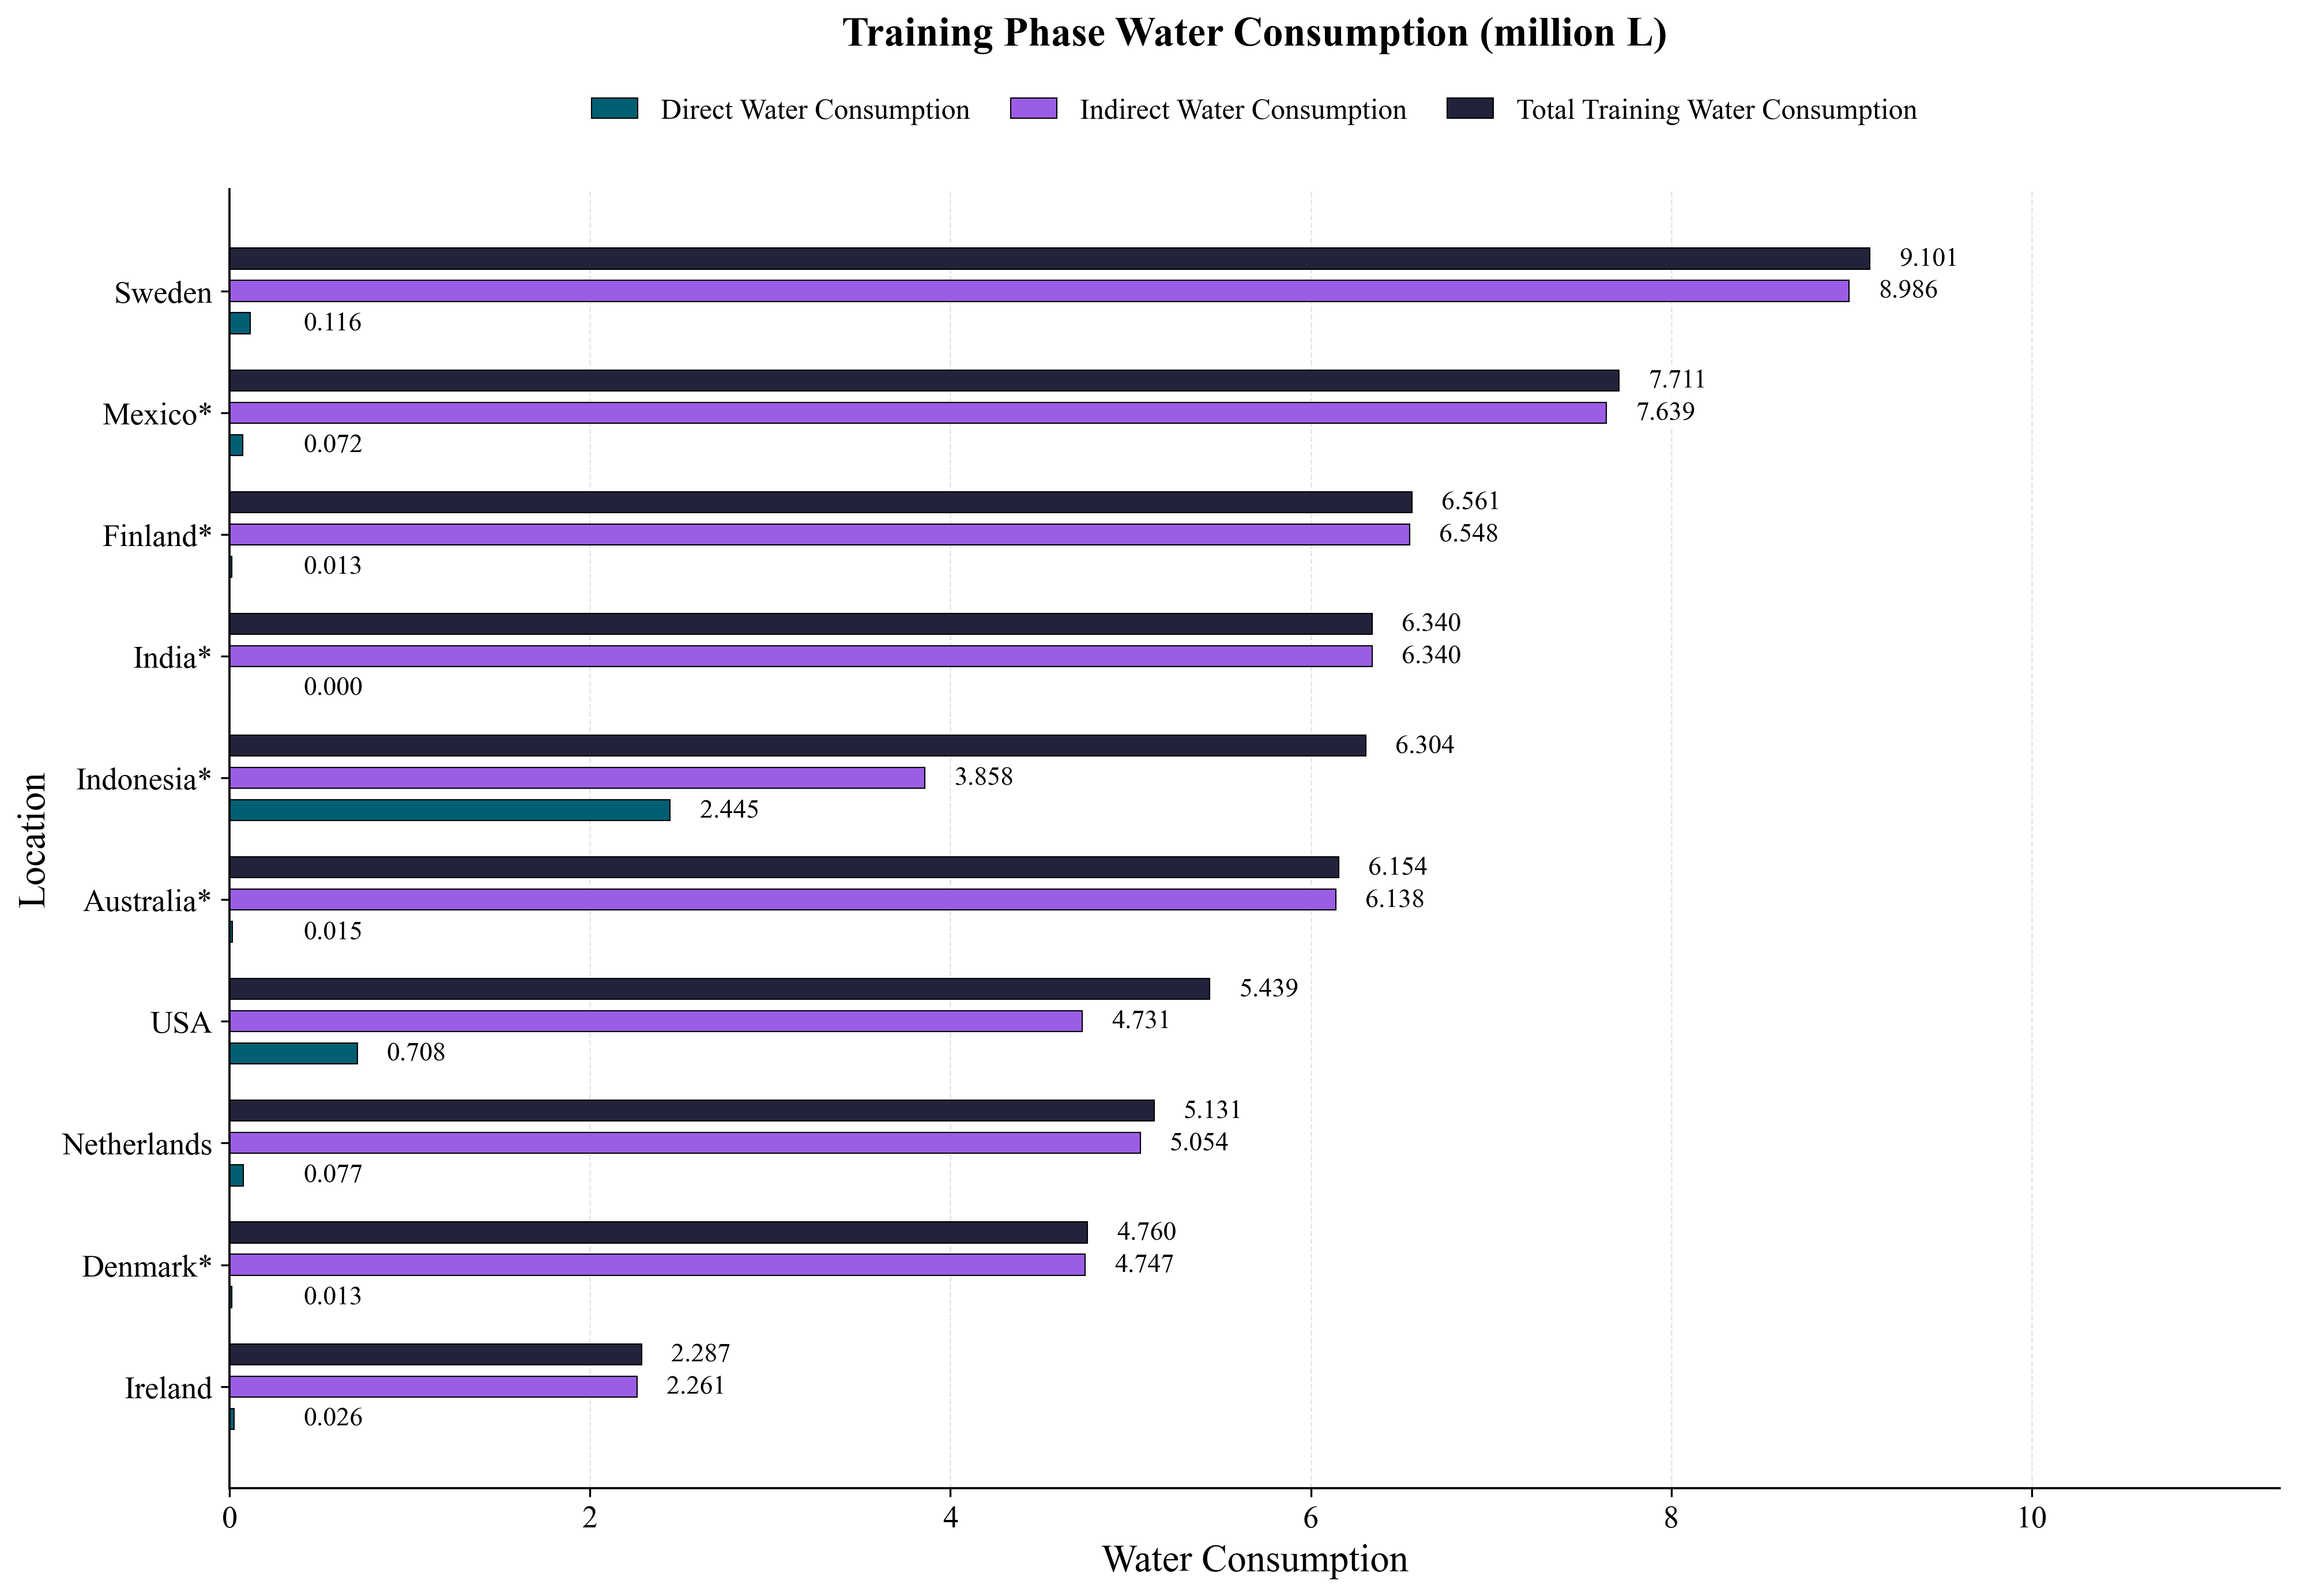

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Data
# -----------------------------
data = {
    "Location": [
        "USA", "Australia*", "Denmark*", "Finland*", "India*",
        "Indonesia*", "Ireland", "Mexico*", "Netherlands", "Sweden"
    ],
    "Direct Water Consumption": [
        0.708, 0.015, 0.013, 0.013, 0.000,
        2.445, 0.026, 0.072, 0.077, 0.116
    ],
    "Indirect Water Consumption": [
        4.731, 6.138, 4.747, 6.548, 6.340,
        3.858, 2.261, 7.639, 5.054, 8.986
    ],
    "Total Training Water Consumption": [
        5.439, 6.154, 4.760, 6.561, 6.340,
        6.304, 2.287, 7.711, 5.131, 9.101
    ]
}

df = pd.DataFrame(data)

# Sort by total water consumption
df = df.sort_values("Total Training Water Consumption", ascending=True)

# -----------------------------
# Journal-style formatting
# -----------------------------
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 14
plt.rcParams["axes.labelsize"] = 16
plt.rcParams["axes.titlesize"] = 17
plt.rcParams["legend.fontsize"] = 12
plt.rcParams["xtick.labelsize"] = 13
plt.rcParams["ytick.labelsize"] = 13
plt.rcParams["figure.dpi"] = 300
plt.rcParams["axes.linewidth"] = 0.9

# -----------------------------
# Plot setup
# -----------------------------
locations = df["Location"]

# More spacing between country groups
group_spacing = 2.45
y = np.arange(len(locations)) * group_spacing

# Thicker bars with clear space between them
bar_height = 0.42
bar_offset = 0.65

fig, ax = plt.subplots(figsize=(13.5, 10.5))

colors = {
    "direct": "#005F73",
    "indirect": "#9B5DE5",
    "total": "#22223B"
}

# -----------------------------
# Horizontal grouped bars
# -----------------------------
bars1 = ax.barh(
    y - bar_offset,
    df["Direct Water Consumption"],
    height=bar_height,
    color=colors["direct"],
    edgecolor="black",
    linewidth=0.5,
    label="Direct Water Consumption"
)

bars2 = ax.barh(
    y,
    df["Indirect Water Consumption"],
    height=bar_height,
    color=colors["indirect"],
    edgecolor="black",
    linewidth=0.5,
    label="Indirect Water Consumption"
)

bars3 = ax.barh(
    y + bar_offset,
    df["Total Training Water Consumption"],
    height=bar_height,
    color=colors["total"],
    edgecolor="black",
    linewidth=0.5,
    label="Total Training Water Consumption"
)

# -----------------------------
# Axes, labels, title
# -----------------------------
ax.set_yticks(y)
ax.set_yticklabels(locations)

ax.set_xlabel("Water Consumption")
ax.set_ylabel("Location")

ax.set_title(
    "Training Phase Water Consumption (million L)",
    pad=60,
    fontweight="bold"
)

# -----------------------------
# Gridlines
# -----------------------------
ax.grid(
    axis="x",
    linestyle="--",
    linewidth=0.6,
    alpha=0.35
)

ax.set_axisbelow(True)

# -----------------------------
# All value labels outside bars
# -----------------------------
max_value = df["Total Training Water Consumption"].max()

outside_offset = max_value * 0.018
minimum_x = max_value * 0.045

def add_outside_labels(bars, values):
    for bar, value in zip(bars, values):
        width = bar.get_width()
        y_pos = bar.get_y() + bar.get_height() / 2

        # Keeps very small values clearly visible
        label_x = max(width + outside_offset, minimum_x)

        ax.text(
            label_x,
            y_pos,
            f"{value:.3f}",
            va="center",
            ha="left",
            fontsize=11,
            color="black",
            clip_on=False,
            bbox=dict(
                facecolor="white",
                edgecolor="none",
                alpha=0.80,
                pad=1.5
            )
        )

add_outside_labels(bars1, df["Direct Water Consumption"])
add_outside_labels(bars2, df["Indirect Water Consumption"])
add_outside_labels(bars3, df["Total Training Water Consumption"])

# -----------------------------
# Legend
# -----------------------------
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.09),
    ncol=3,
    frameon=False,
    handlelength=1.6,
    columnspacing=1.4
)

# -----------------------------
# Borders and limits
# -----------------------------
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_linewidth(0.9)
ax.spines["bottom"].set_linewidth(0.9)

# Extra x-axis room for outside labels
ax.set_xlim(0, max_value * 1.25)

# Extra vertical breathing space
ax.margins(y=0.05)

plt.tight_layout(rect=[0, 0, 1, 0.90])

# -----------------------------
# Save high-resolution files
# -----------------------------
plt.savefig(
    "training_phase_water_consumption_thicker_all_labels_outside.png",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "training_phase_water_consumption_thicker_all_labels_outside.pdf",
    bbox_inches="tight"
)

plt.show()

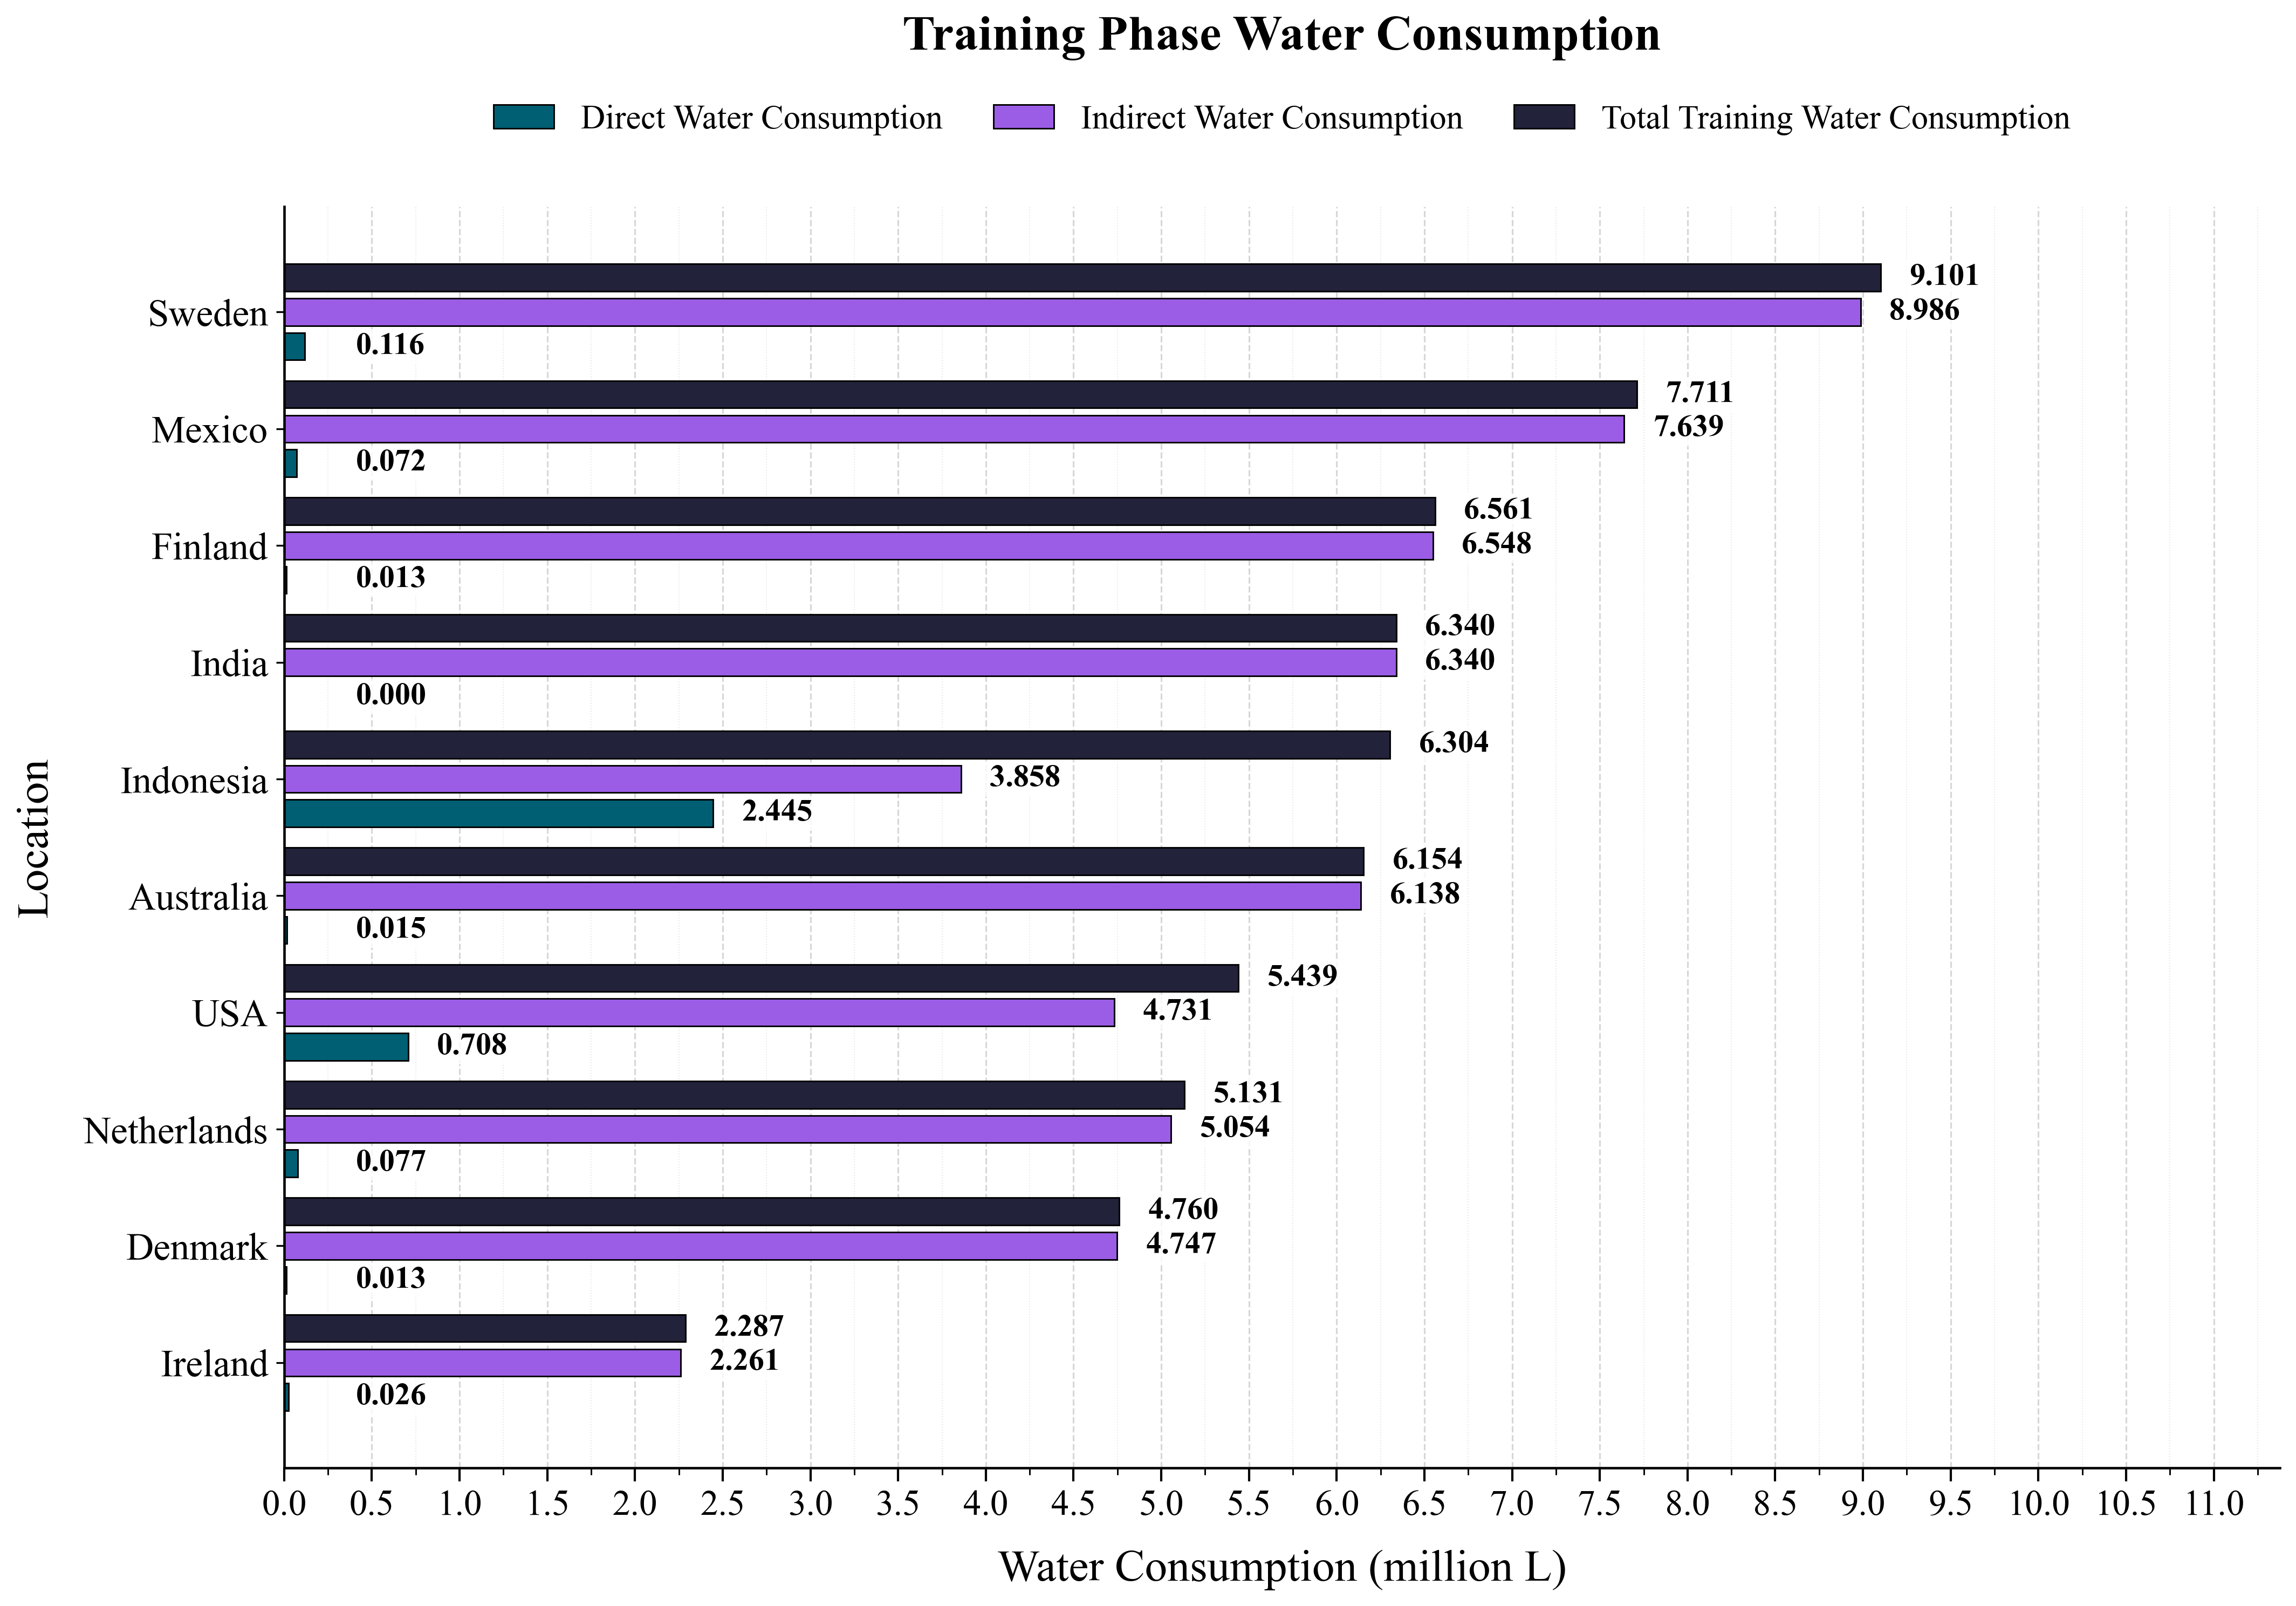

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MultipleLocator

# -----------------------------
# Data
# -----------------------------
data = {
    "Location": [
        "USA", "Australia*", "Denmark*", "Finland*", "India*",
        "Indonesia*", "Ireland", "Mexico*", "Netherlands", "Sweden"
    ],
    "Direct Water Consumption": [
        0.708, 0.015, 0.013, 0.013, 0.000,
        2.445, 0.026, 0.072, 0.077, 0.116
    ],
    "Indirect Water Consumption": [
        4.731, 6.138, 4.747, 6.548, 6.340,
        3.858, 2.261, 7.639, 5.054, 8.986
    ],
    "Total Training Water Consumption": [
        5.439, 6.154, 4.760, 6.561, 6.340,
        6.304, 2.287, 7.711, 5.131, 9.101
    ]
}

df = pd.DataFrame(data)

# Remove "*" marks from country names
df["Location"] = df["Location"].str.replace("*", "", regex=False)

# Sort by total water consumption
df = df.sort_values(
    "Total Training Water Consumption",
    ascending=True
)

# -----------------------------
# Journal-style formatting
# -----------------------------
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 17
plt.rcParams["axes.labelsize"] = 20
plt.rcParams["axes.titlesize"] = 22
plt.rcParams["legend.fontsize"] = 15
plt.rcParams["xtick.labelsize"] = 16
plt.rcParams["ytick.labelsize"] = 17
plt.rcParams["figure.dpi"] = 300
plt.rcParams["axes.linewidth"] = 1.1

# -----------------------------
# Plot setup
# -----------------------------
locations = df["Location"]

group_spacing = 2.65
y = np.arange(len(locations)) * group_spacing

# Thicker bars
bar_height = 0.62
bar_offset = 0.78

fig, ax = plt.subplots(figsize=(14.5, 11.5))

colors = {
    "direct": "#005F73",
    "indirect": "#9B5DE5",
    "total": "#22223B"
}

# -----------------------------
# Horizontal grouped bars
# -----------------------------
bars1 = ax.barh(
    y - bar_offset,
    df["Direct Water Consumption"],
    height=bar_height,
    color=colors["direct"],
    edgecolor="black",
    linewidth=0.7,
    label="Direct Water Consumption"
)

bars2 = ax.barh(
    y,
    df["Indirect Water Consumption"],
    height=bar_height,
    color=colors["indirect"],
    edgecolor="black",
    linewidth=0.7,
    label="Indirect Water Consumption"
)

bars3 = ax.barh(
    y + bar_offset,
    df["Total Training Water Consumption"],
    height=bar_height,
    color=colors["total"],
    edgecolor="black",
    linewidth=0.7,
    label="Total Training Water Consumption"
)

# -----------------------------
# Axes, labels and title
# -----------------------------
ax.set_yticks(y)
ax.set_yticklabels(locations)

ax.set_xlabel("Water Consumption (million L)", labelpad=12)
ax.set_ylabel("Location", labelpad=12)

ax.set_title(
    "Training Phase Water Consumption",
    pad=70,
    fontweight="bold"
)

# -----------------------------
# More x-axis scale points
# -----------------------------
ax.xaxis.set_major_locator(MultipleLocator(0.5))
ax.xaxis.set_minor_locator(MultipleLocator(0.25))

# Major and minor gridlines
ax.grid(
    axis="x",
    which="major",
    linestyle="--",
    linewidth=0.75,
    alpha=0.50
)

ax.grid(
    axis="x",
    which="minor",
    linestyle=":",
    linewidth=0.45,
    alpha=0.30
)

ax.tick_params(
    axis="x",
    which="major",
    length=6,
    width=1
)

ax.tick_params(
    axis="x",
    which="minor",
    length=3,
    width=0.7
)

ax.set_axisbelow(True)

# -----------------------------
# Bigger value labels outside bars
# -----------------------------
max_value = df["Total Training Water Consumption"].max()

outside_offset = max_value * 0.018
minimum_x = max_value * 0.045

def add_outside_labels(bars, values):
    for bar, value in zip(bars, values):
        width = bar.get_width()
        y_pos = bar.get_y() + bar.get_height() / 2

        label_x = max(width + outside_offset, minimum_x)

        ax.text(
            label_x,
            y_pos,
            f"{value:.3f}",
            va="center",
            ha="left",
            fontsize=14,
            fontweight="semibold",
            color="black",
            clip_on=False,
            bbox=dict(
                facecolor="white",
                edgecolor="none",
                alpha=0.82,
                pad=1.8
            )
        )

add_outside_labels(
    bars1,
    df["Direct Water Consumption"]
)

add_outside_labels(
    bars2,
    df["Indirect Water Consumption"]
)

add_outside_labels(
    bars3,
    df["Total Training Water Consumption"]
)

# -----------------------------
# Legend
# -----------------------------
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.105),
    ncol=3,
    frameon=False,
    handlelength=1.8,
    columnspacing=1.5
)

# -----------------------------
# Borders and limits
# -----------------------------
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_linewidth(1.1)
ax.spines["bottom"].set_linewidth(1.1)

ax.set_xlim(0, max_value * 1.25)
ax.margins(y=0.05)

plt.tight_layout(rect=[0, 0, 1, 0.89])

# -----------------------------
# Save high-resolution files
# -----------------------------
plt.savefig(
    "training_phase_water_consumption_updated.png",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "training_phase_water_consumption_updated.pdf",
    bbox_inches="tight"
)

plt.show()

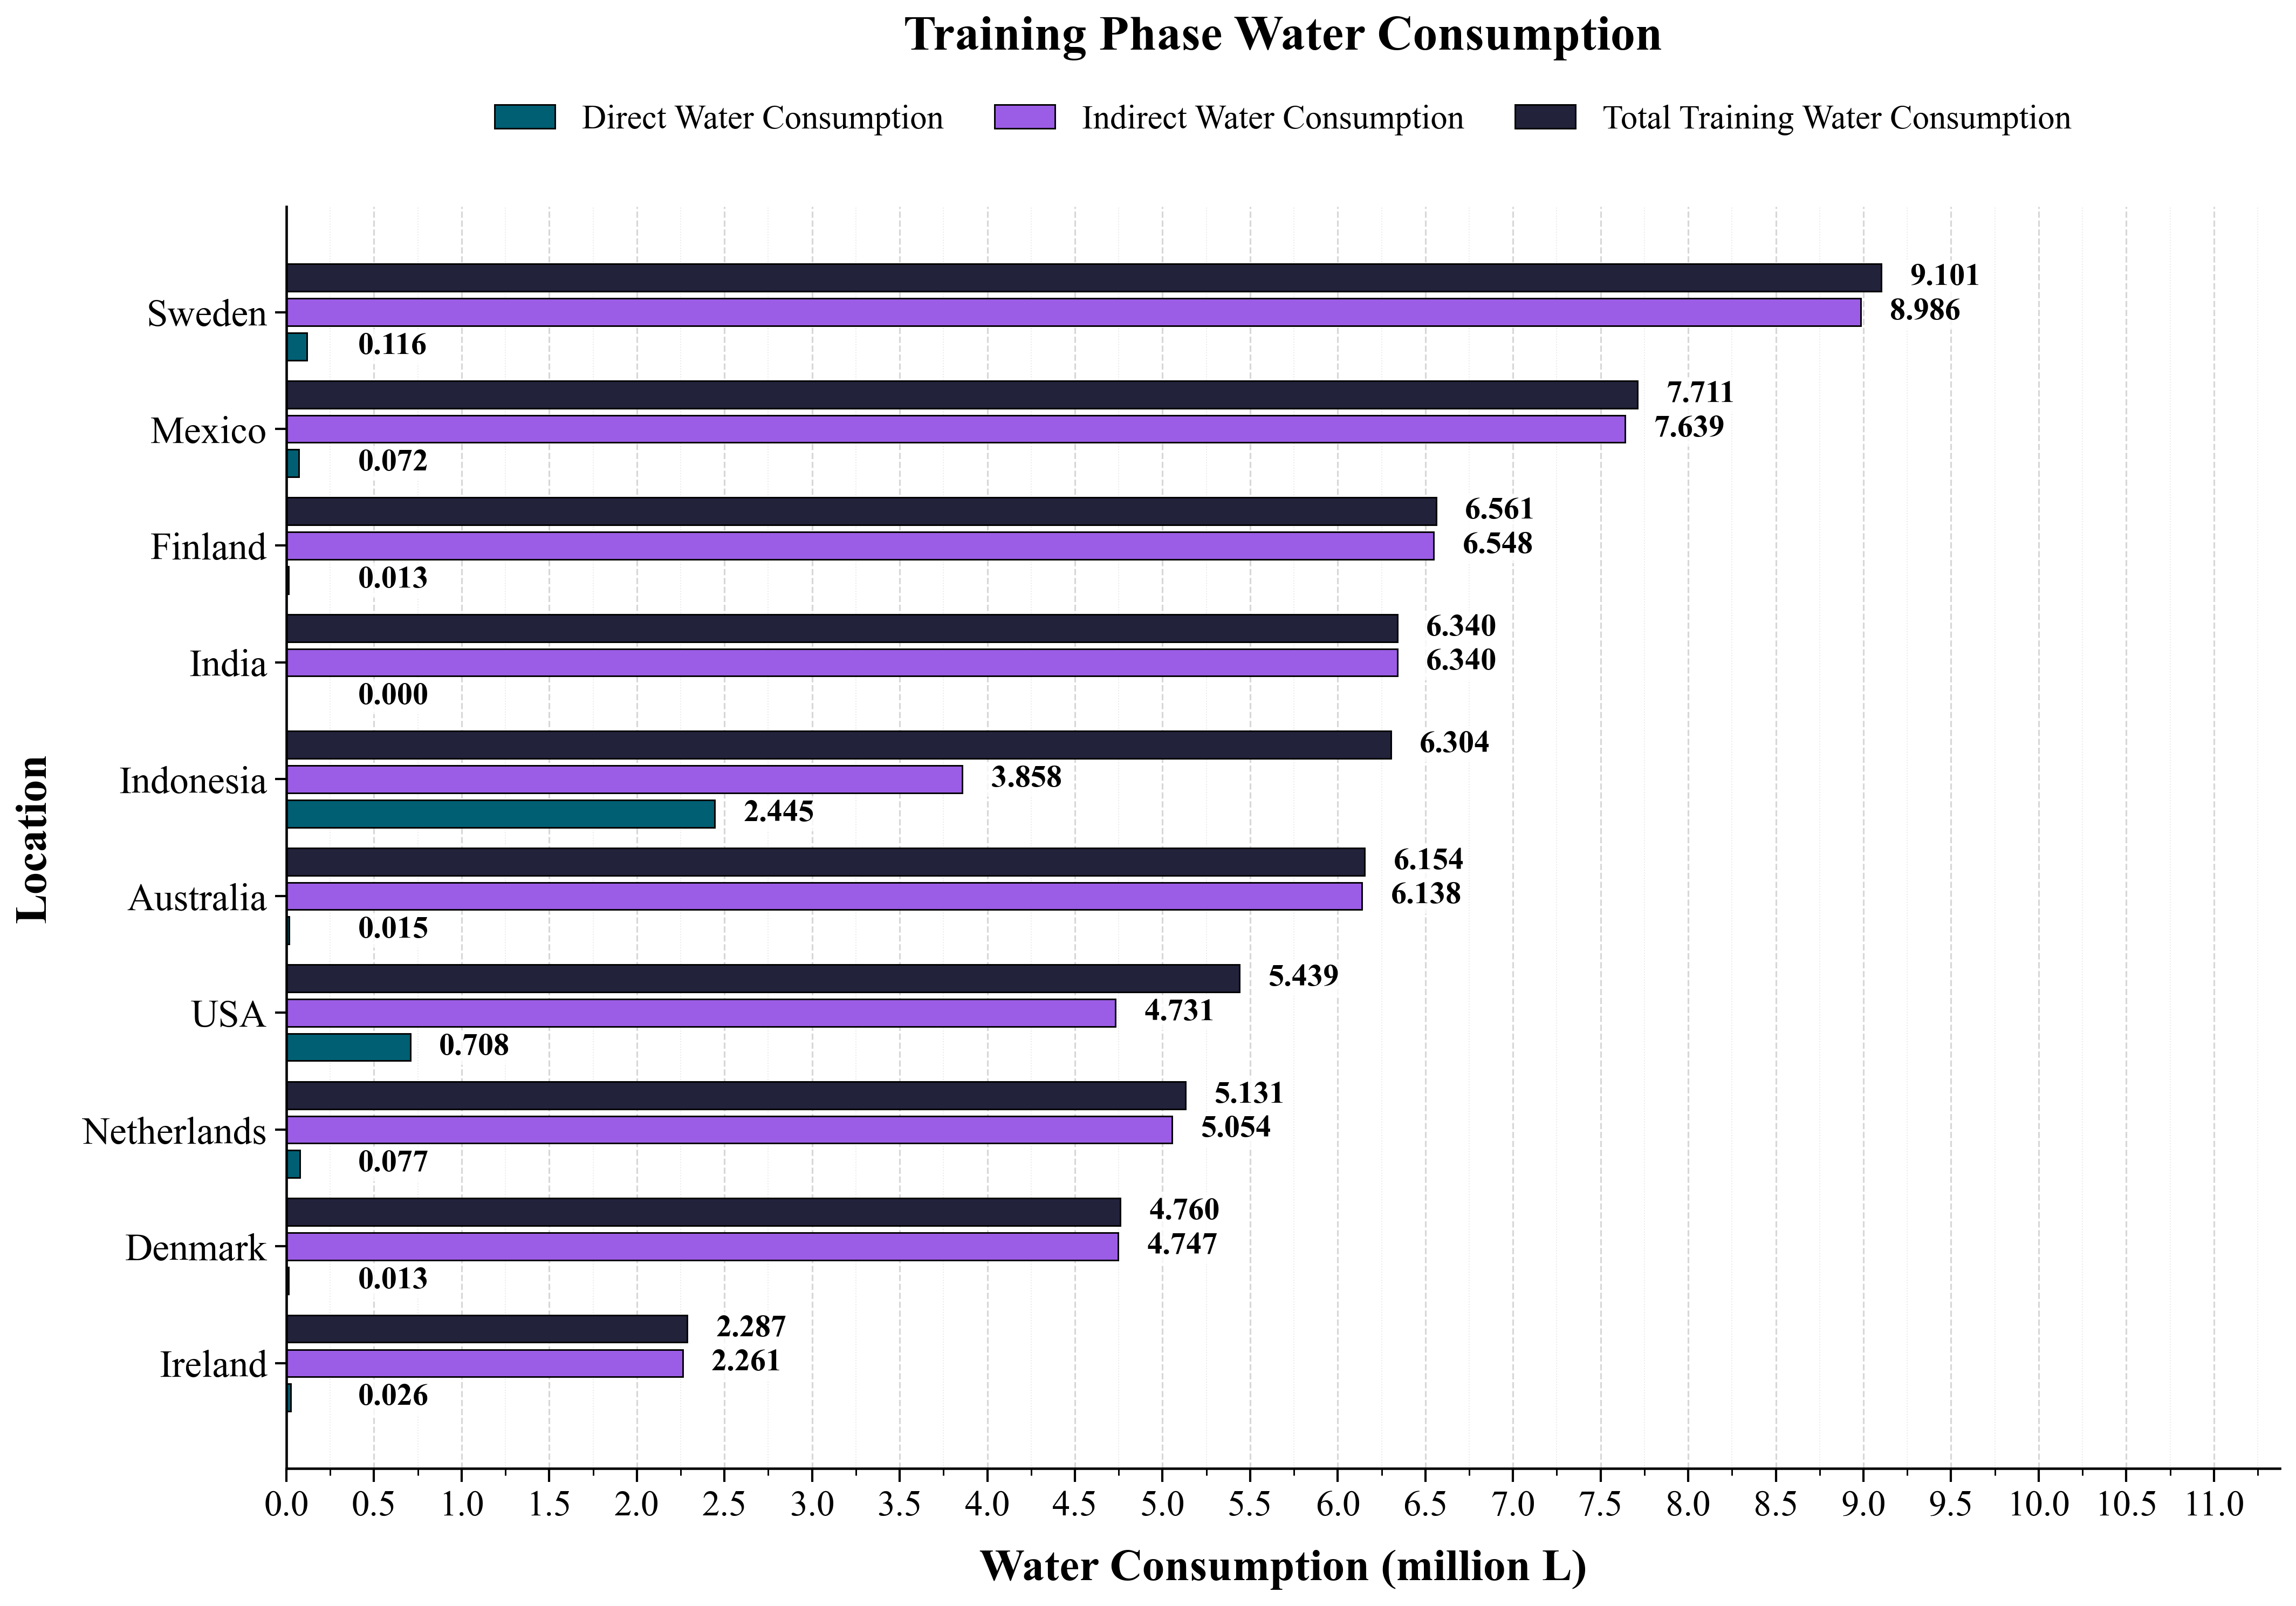

Files saved successfully in the current folder:
training_phase_water_consumption_transparent.svg
training_phase_water_consumption_transparent.pdf
training_phase_water_consumption_transparent.png


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MultipleLocator

# -----------------------------
# Data
# -----------------------------
data = {
    "Location": [
        "USA", "Australia*", "Denmark*", "Finland*", "India*",
        "Indonesia*", "Ireland", "Mexico*", "Netherlands", "Sweden"
    ],
    "Direct Water Consumption": [
        0.708, 0.015, 0.013, 0.013, 0.000,
        2.445, 0.026, 0.072, 0.077, 0.116
    ],
    "Indirect Water Consumption": [
        4.731, 6.138, 4.747, 6.548, 6.340,
        3.858, 2.261, 7.639, 5.054, 8.986
    ],
    "Total Training Water Consumption": [
        5.439, 6.154, 4.760, 6.561, 6.340,
        6.304, 2.287, 7.711, 5.131, 9.101
    ]
}

df = pd.DataFrame(data)

# Remove "*" marks from country names
df["Location"] = df["Location"].str.replace("*", "", regex=False)

# Sort by total water consumption
df = df.sort_values(
    "Total Training Water Consumption",
    ascending=True
).reset_index(drop=True)

# -----------------------------
# Journal-style formatting
# -----------------------------
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 17
plt.rcParams["axes.labelsize"] = 20
plt.rcParams["axes.titlesize"] = 22
plt.rcParams["legend.fontsize"] = 15
plt.rcParams["xtick.labelsize"] = 16
plt.rcParams["ytick.labelsize"] = 17
plt.rcParams["figure.dpi"] = 300
plt.rcParams["axes.linewidth"] = 1.1

# -----------------------------
# Plot setup
# -----------------------------
locations = df["Location"]

# Spacing between country groups
group_spacing = 2.65
y = np.arange(len(locations)) * group_spacing

# Thicker bars
bar_height = 0.62
bar_offset = 0.78

fig, ax = plt.subplots(figsize=(14.5, 11.5))

# Transparent figure and axes backgrounds
fig.patch.set_alpha(0)
ax.patch.set_alpha(0)

colors = {
    "direct": "#005F73",
    "indirect": "#9B5DE5",
    "total": "#22223B"
}

# -----------------------------
# Horizontal grouped bars
# -----------------------------
bars1 = ax.barh(
    y - bar_offset,
    df["Direct Water Consumption"],
    height=bar_height,
    color=colors["direct"],
    edgecolor="black",
    linewidth=0.7,
    label="Direct Water Consumption"
)

bars2 = ax.barh(
    y,
    df["Indirect Water Consumption"],
    height=bar_height,
    color=colors["indirect"],
    edgecolor="black",
    linewidth=0.7,
    label="Indirect Water Consumption"
)

bars3 = ax.barh(
    y + bar_offset,
    df["Total Training Water Consumption"],
    height=bar_height,
    color=colors["total"],
    edgecolor="black",
    linewidth=0.7,
    label="Total Training Water Consumption"
)

# -----------------------------
# Axes, labels and title
# -----------------------------
ax.set_yticks(y)
ax.set_yticklabels(locations)

ax.set_xlabel(
    "Water Consumption (million L)",
    labelpad=12,
    fontweight="bold"
)

ax.set_ylabel(
    "Location",
    labelpad=12,
    fontweight="bold"
)

ax.set_title(
    "Training Phase Water Consumption",
    pad=70,
    fontweight="bold"
)

# -----------------------------
# More x-axis scale points
# -----------------------------
# Major scale points every 0.5
ax.xaxis.set_major_locator(MultipleLocator(0.5))

# Minor scale points every 0.25
ax.xaxis.set_minor_locator(MultipleLocator(0.25))

# Major gridlines
ax.grid(
    axis="x",
    which="major",
    linestyle="--",
    linewidth=0.75,
    alpha=0.50
)

# Minor gridlines
ax.grid(
    axis="x",
    which="minor",
    linestyle=":",
    linewidth=0.45,
    alpha=0.30
)

ax.tick_params(
    axis="x",
    which="major",
    length=6,
    width=1
)

ax.tick_params(
    axis="x",
    which="minor",
    length=3,
    width=0.7
)

ax.tick_params(
    axis="y",
    which="major",
    length=5,
    width=1
)

ax.set_axisbelow(True)

# -----------------------------
# Bigger value labels outside bars
# -----------------------------
max_value = df["Total Training Water Consumption"].max()

outside_offset = max_value * 0.018
minimum_x = max_value * 0.045

def add_outside_labels(bars, values):
    for bar, value in zip(bars, values):
        width = bar.get_width()
        y_position = bar.get_y() + bar.get_height() / 2

        # Keep labels for very small values visible
        label_x = max(width + outside_offset, minimum_x)

        ax.text(
            label_x,
            y_position,
            f"{value:.3f}",
            va="center",
            ha="left",
            fontsize=14,
            fontweight="semibold",
            color="black",
            clip_on=False,
            bbox=dict(
                facecolor="white",
                edgecolor="none",
                alpha=0.80,
                pad=1.8
            )
        )

add_outside_labels(
    bars1,
    df["Direct Water Consumption"]
)

add_outside_labels(
    bars2,
    df["Indirect Water Consumption"]
)

add_outside_labels(
    bars3,
    df["Total Training Water Consumption"]
)

# -----------------------------
# Legend
# -----------------------------
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.105),
    ncol=3,
    frameon=False,
    handlelength=1.8,
    columnspacing=1.5
)

# -----------------------------
# Borders and limits
# -----------------------------
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_linewidth(1.1)
ax.spines["bottom"].set_linewidth(1.1)

# Extra room for outside labels
ax.set_xlim(0, max_value * 1.25)

# Extra vertical spacing
ax.margins(y=0.05)

plt.tight_layout(rect=[0, 0, 1, 0.89])

# -----------------------------
# Output filenames
# -----------------------------
output_svg = "training_phase_water_consumption_transparent.svg"
output_pdf = "training_phase_water_consumption_transparent.pdf"
output_png = "training_phase_water_consumption_transparent.png"

# -----------------------------
# Save lossless transparent files
# -----------------------------

# SVG: lossless vector format
fig.savefig(
    output_svg,
    format="svg",
    transparent=True,
    bbox_inches="tight",
    facecolor="none",
    edgecolor="none"
)

# PDF: lossless vector format
fig.savefig(
    output_pdf,
    format="pdf",
    transparent=True,
    bbox_inches="tight",
    facecolor="none",
    edgecolor="none"
)

# PNG: lossless raster format at 600 DPI
fig.savefig(
    output_png,
    format="png",
    dpi=600,
    transparent=True,
    bbox_inches="tight",
    facecolor="none",
    edgecolor="none"
)

plt.show()

# -----------------------------
# Download files in Google Colab
# -----------------------------
# This section runs only when using Google Colab.

try:
    from google.colab import files

    files.download(output_svg)
    files.download(output_pdf)
    files.download(output_png)

except ImportError:
    print("Files saved successfully in the current folder:")
    print(output_svg)
    print(output_pdf)
    print(output_png)

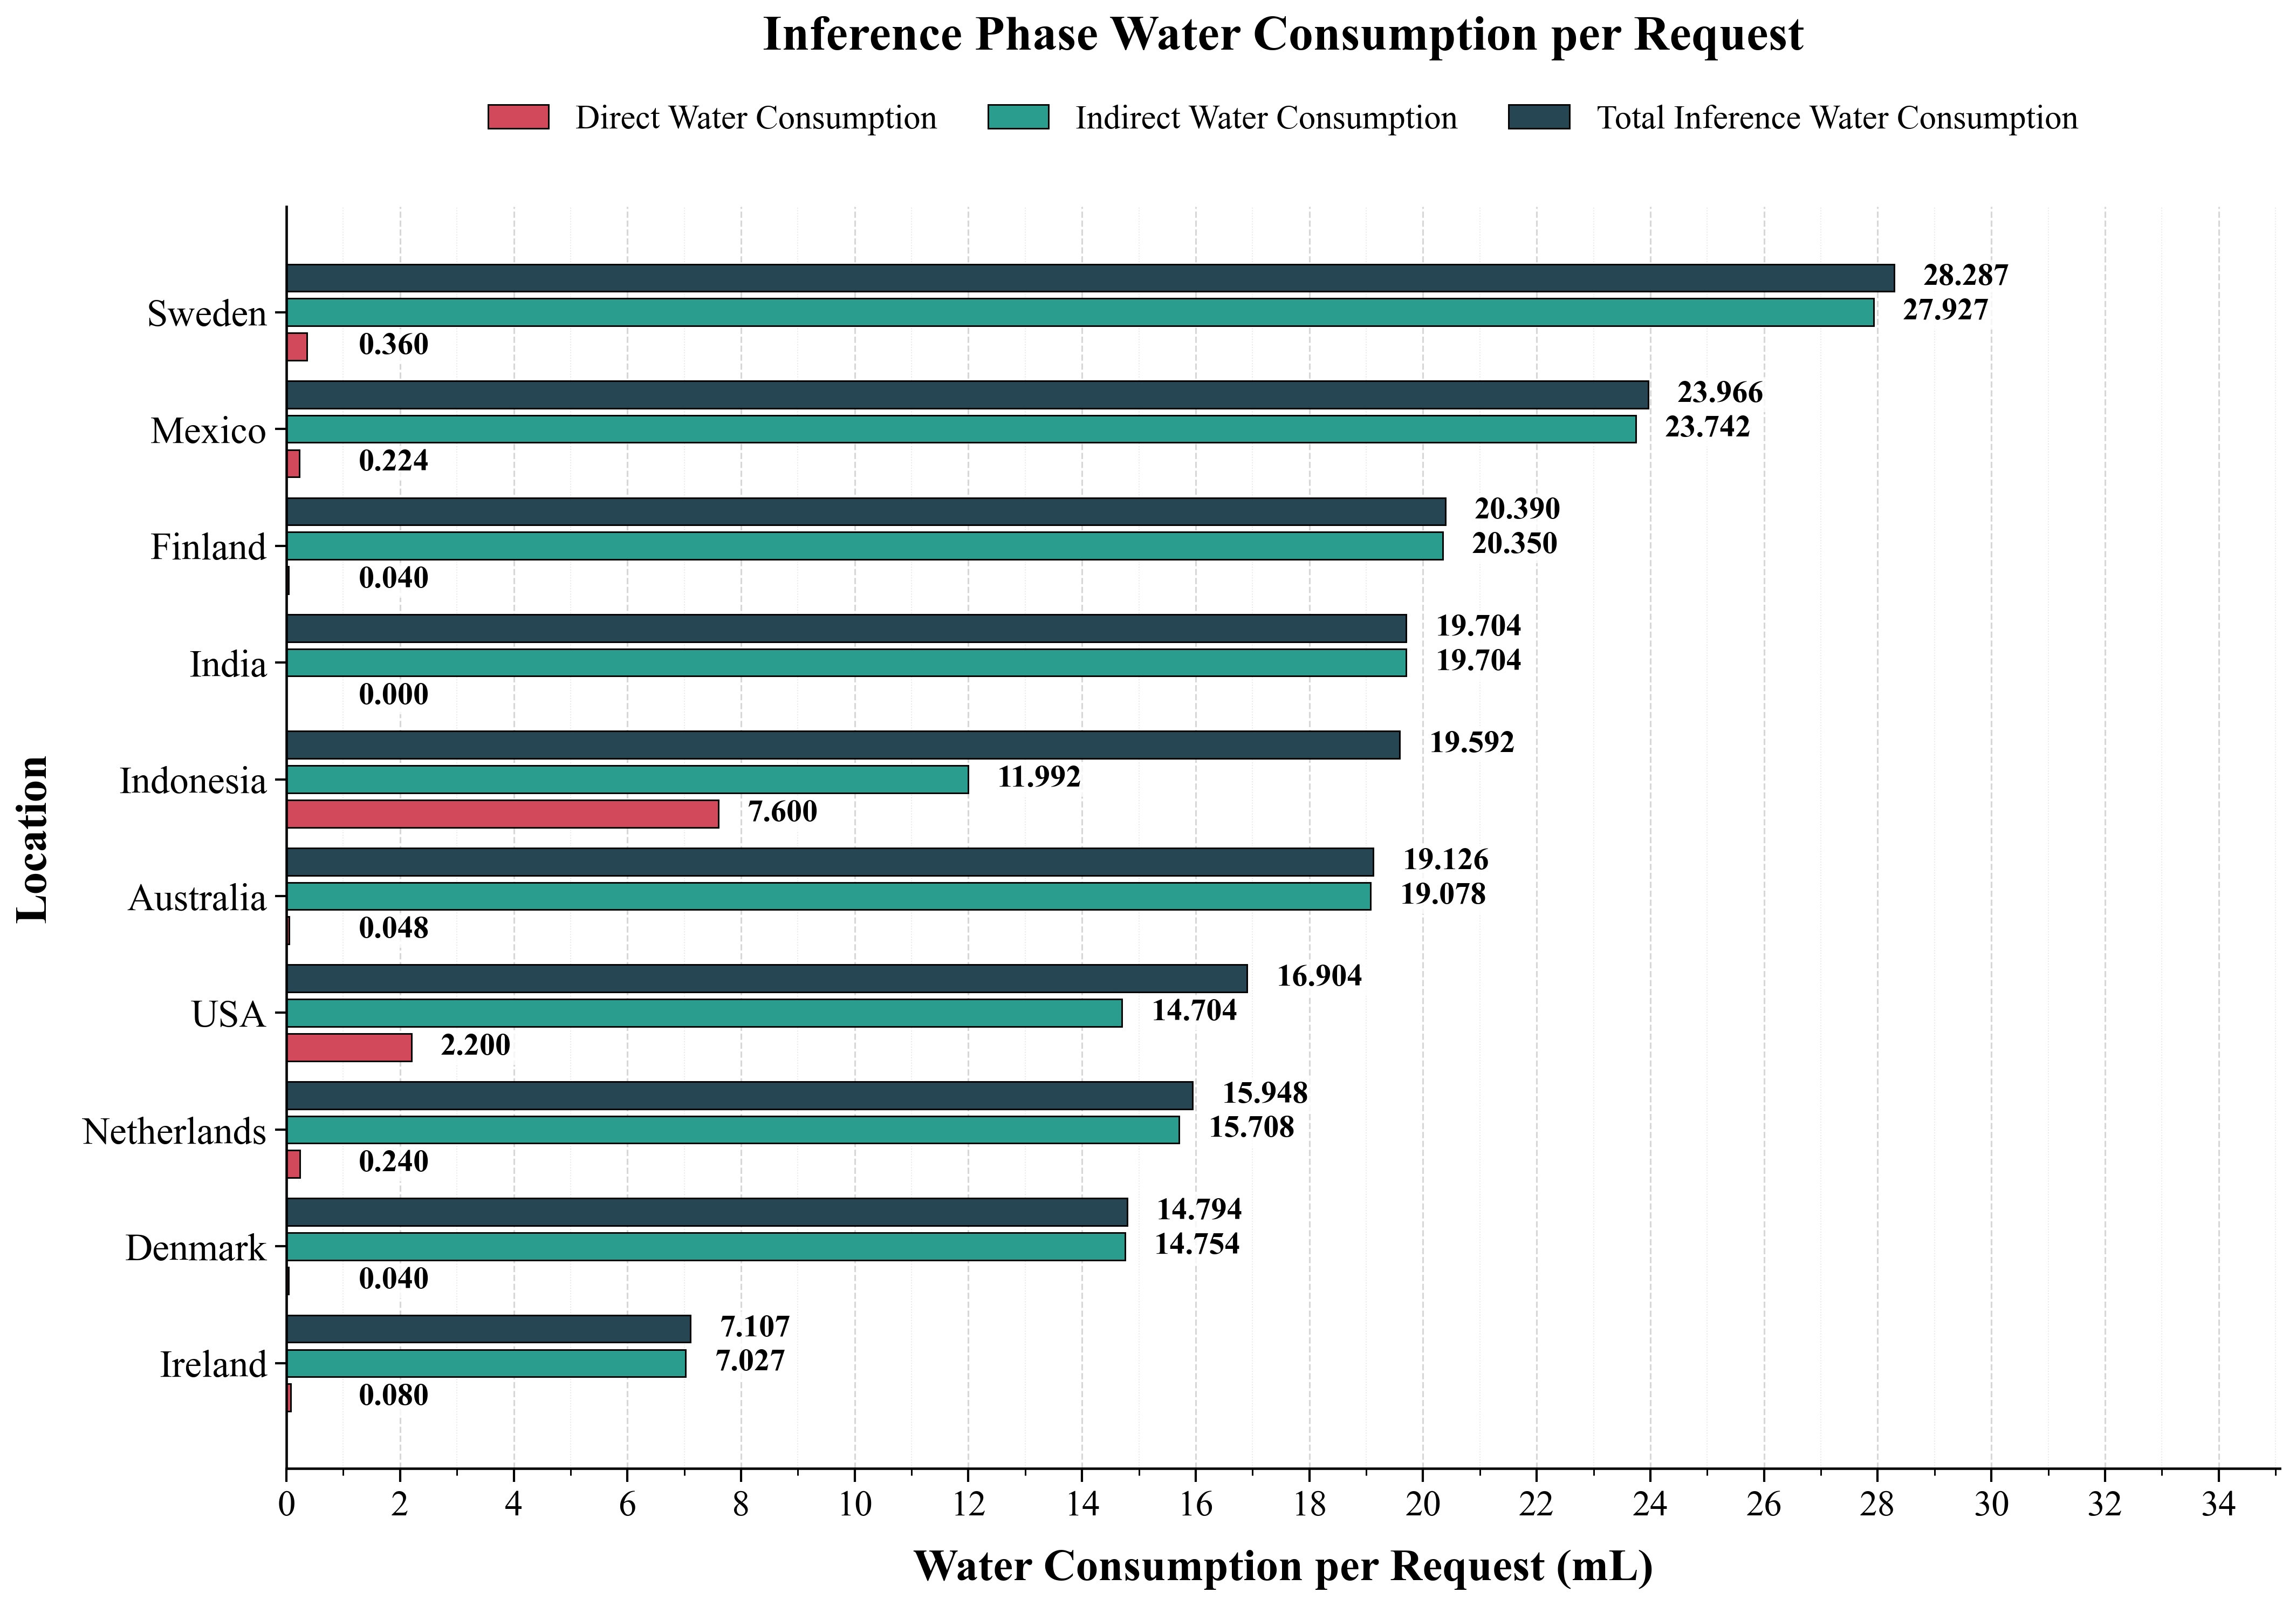

Files saved successfully in the current folder:
inference_phase_water_consumption_transparent.svg
inference_phase_water_consumption_transparent.pdf
inference_phase_water_consumption_transparent.png


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MultipleLocator

# -----------------------------
# Data
# -----------------------------
data = {
    "Location": [
        "USA", "Australia", "Denmark", "Finland", "India",
        "Indonesia", "Ireland", "Mexico", "Netherlands", "Sweden"
    ],
    "Direct Water Consumption": [
        2.200, 0.048, 0.040, 0.040, 0.000,
        7.600, 0.080, 0.224, 0.240, 0.360
    ],
    "Indirect Water Consumption": [
        14.704, 19.078, 14.754, 20.350, 19.704,
        11.992, 7.027, 23.742, 15.708, 27.927
    ],
    "Total Inference Water Consumption": [
        16.904, 19.126, 14.794, 20.390, 19.704,
        19.592, 7.107, 23.966, 15.948, 28.287
    ]
}

df = pd.DataFrame(data)

# Sort locations by total inference water consumption
df = df.sort_values(
    "Total Inference Water Consumption",
    ascending=True
).reset_index(drop=True)

# -----------------------------
# Journal-style formatting
# -----------------------------
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 17
plt.rcParams["axes.labelsize"] = 20
plt.rcParams["axes.titlesize"] = 22
plt.rcParams["legend.fontsize"] = 15
plt.rcParams["xtick.labelsize"] = 16
plt.rcParams["ytick.labelsize"] = 17
plt.rcParams["figure.dpi"] = 300
plt.rcParams["axes.linewidth"] = 1.1

# -----------------------------
# Plot setup
# -----------------------------
locations = df["Location"]

# Spacing between location groups
group_spacing = 2.65
y = np.arange(len(locations)) * group_spacing

# Thick bars
bar_height = 0.62
bar_offset = 0.78

fig, ax = plt.subplots(figsize=(14.5, 11.5))

# Transparent figure and axes backgrounds
fig.patch.set_alpha(0)
ax.patch.set_alpha(0)

colors = {
    "direct": "#D1495B",
    "indirect": "#2A9D8F",
    "total": "#264653"
}

# -----------------------------
# Horizontal grouped bars
# -----------------------------
bars1 = ax.barh(
    y - bar_offset,
    df["Direct Water Consumption"],
    height=bar_height,
    color=colors["direct"],
    edgecolor="black",
    linewidth=0.7,
    label="Direct Water Consumption"
)

bars2 = ax.barh(
    y,
    df["Indirect Water Consumption"],
    height=bar_height,
    color=colors["indirect"],
    edgecolor="black",
    linewidth=0.7,
    label="Indirect Water Consumption"
)

bars3 = ax.barh(
    y + bar_offset,
    df["Total Inference Water Consumption"],
    height=bar_height,
    color=colors["total"],
    edgecolor="black",
    linewidth=0.7,
    label="Total Inference Water Consumption"
)

# -----------------------------
# Axes, labels and title
# -----------------------------
ax.set_yticks(y)
ax.set_yticklabels(locations)

ax.set_xlabel(
    "Water Consumption per Request (mL)",
    labelpad=12,
    fontweight="bold"
)

ax.set_ylabel(
    "Location",
    labelpad=12,
    fontweight="bold"
)

ax.set_title(
    "Inference Phase Water Consumption per Request",
    pad=70,
    fontweight="bold"
)

# -----------------------------
# X-axis scale points
# -----------------------------
# Major scale/grid point every 2 mL
ax.xaxis.set_major_locator(MultipleLocator(2))

# Minor scale/grid point every 1 mL
ax.xaxis.set_minor_locator(MultipleLocator(1))

# Major gridlines
ax.grid(
    axis="x",
    which="major",
    linestyle="--",
    linewidth=0.75,
    alpha=0.50
)

# Minor gridlines
ax.grid(
    axis="x",
    which="minor",
    linestyle=":",
    linewidth=0.45,
    alpha=0.30
)

ax.tick_params(
    axis="x",
    which="major",
    length=6,
    width=1
)

ax.tick_params(
    axis="x",
    which="minor",
    length=3,
    width=0.7
)

ax.tick_params(
    axis="y",
    which="major",
    length=5,
    width=1
)

ax.set_axisbelow(True)

# -----------------------------
# Value labels outside bars
# -----------------------------
max_value = df["Total Inference Water Consumption"].max()

outside_offset = max_value * 0.018
minimum_x = max_value * 0.045

def add_outside_labels(bars, values):
    for bar, value in zip(bars, values):
        width = bar.get_width()
        y_position = bar.get_y() + bar.get_height() / 2

        # Keep labels for small or zero values visible
        label_x = max(width + outside_offset, minimum_x)

        ax.text(
            label_x,
            y_position,
            f"{value:.3f}",
            va="center",
            ha="left",
            fontsize=14,
            fontweight="semibold",
            color="black",
            clip_on=False,
            bbox=dict(
                facecolor="white",
                edgecolor="none",
                alpha=0.80,
                pad=1.8
            )
        )

add_outside_labels(
    bars1,
    df["Direct Water Consumption"]
)

add_outside_labels(
    bars2,
    df["Indirect Water Consumption"]
)

add_outside_labels(
    bars3,
    df["Total Inference Water Consumption"]
)

# -----------------------------
# Legend
# -----------------------------
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.105),
    ncol=3,
    frameon=False,
    handlelength=1.8,
    columnspacing=1.5
)

# -----------------------------
# Borders and limits
# -----------------------------
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_linewidth(1.1)
ax.spines["bottom"].set_linewidth(1.1)

# Extra horizontal space for outside labels
ax.set_xlim(0, max_value * 1.24)

# Extra vertical breathing space
ax.margins(y=0.05)

plt.tight_layout(rect=[0, 0, 1, 0.89])

# -----------------------------
# Output filenames
# -----------------------------
output_svg = "inference_phase_water_consumption_transparent.svg"
output_pdf = "inference_phase_water_consumption_transparent.pdf"
output_png = "inference_phase_water_consumption_transparent.png"

# -----------------------------
# Save transparent lossless files
# -----------------------------

# SVG: lossless scalable vector format
fig.savefig(
    output_svg,
    format="svg",
    transparent=True,
    bbox_inches="tight",
    facecolor="none",
    edgecolor="none"
)

# PDF: lossless vector format
fig.savefig(
    output_pdf,
    format="pdf",
    transparent=True,
    bbox_inches="tight",
    facecolor="none",
    edgecolor="none"
)

# PNG: lossless raster format at 600 DPI
fig.savefig(
    output_png,
    format="png",
    dpi=600,
    transparent=True,
    bbox_inches="tight",
    facecolor="none",
    edgecolor="none"
)

plt.show()

# -----------------------------
# Download files in Google Colab
# -----------------------------
try:
    from google.colab import files

    files.download(output_svg)
    files.download(output_pdf)
    files.download(output_png)

except ImportError:
    print("Files saved successfully in the current folder:")
    print(output_svg)
    print(output_pdf)
    print(output_png)

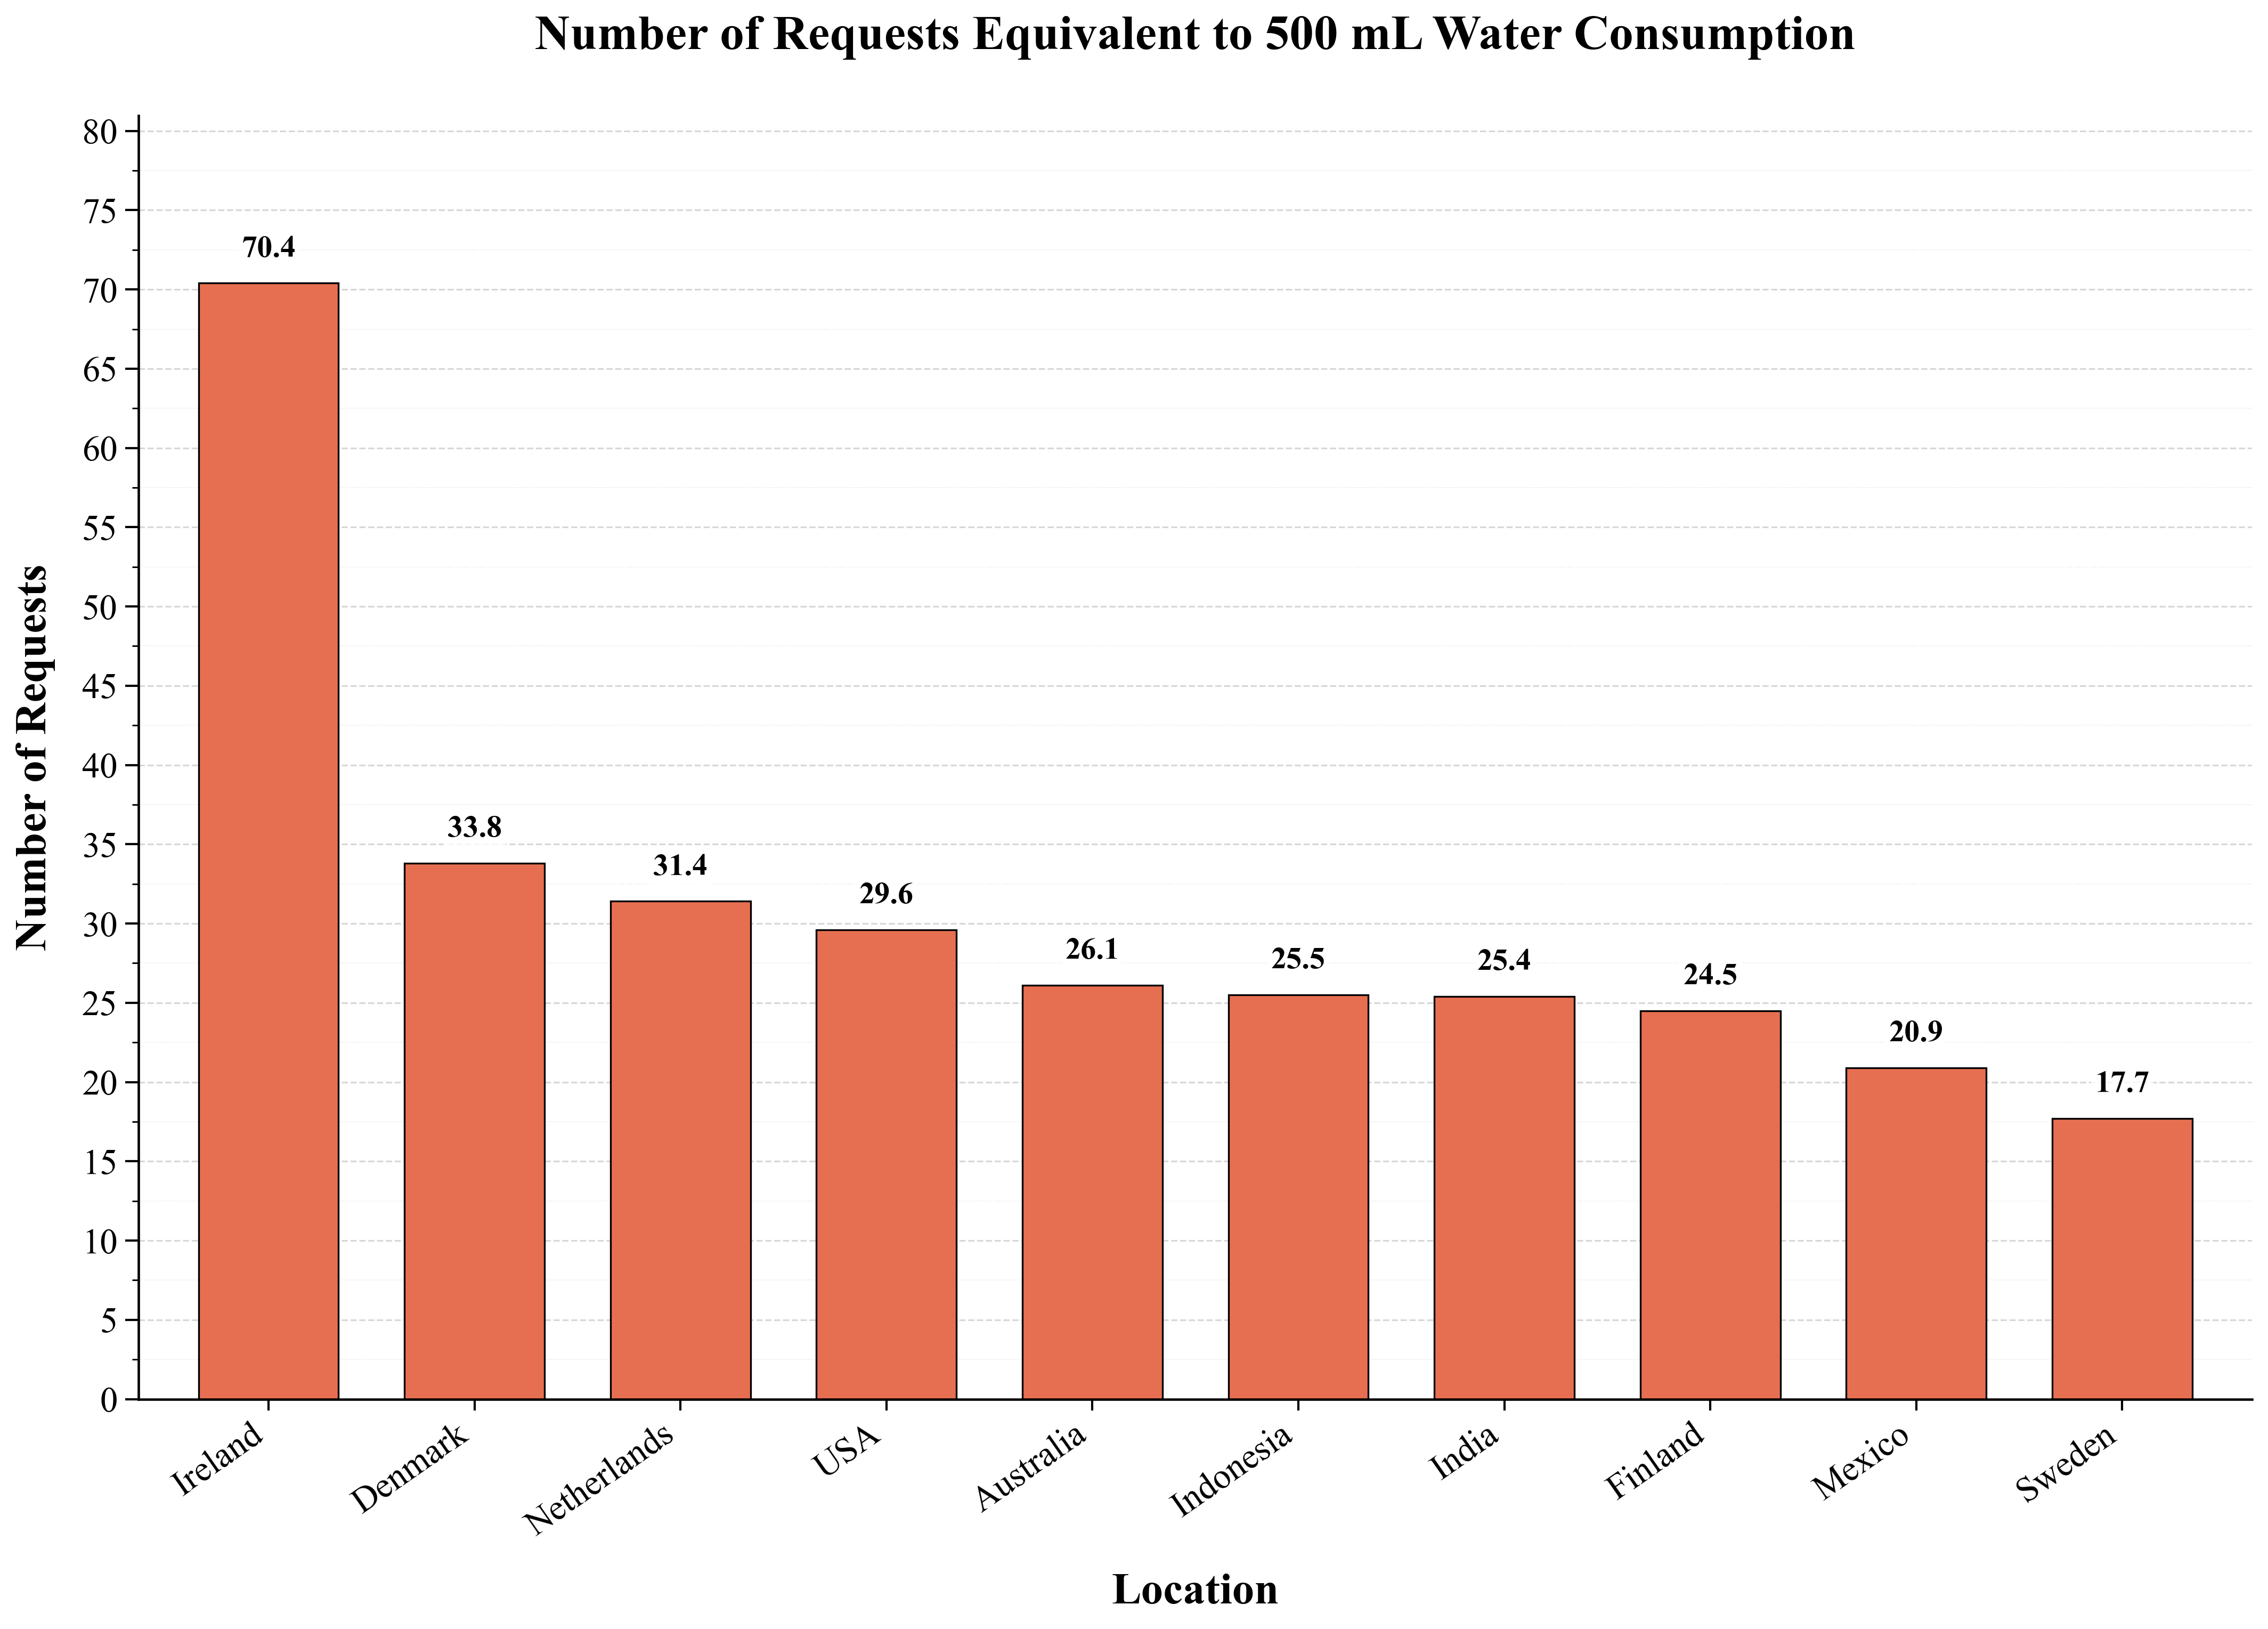

Files saved successfully in the current folder:
requests_equivalent_to_500ml_transparent.svg
requests_equivalent_to_500ml_transparent.pdf
requests_equivalent_to_500ml_transparent.png


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MultipleLocator

# -----------------------------
# Data
# -----------------------------
data = {
    "Location": [
        "USA", "Australia", "Denmark", "Finland", "India",
        "Indonesia", "Ireland", "Mexico", "Netherlands", "Sweden"
    ],
    "Number of Requests": [
        29.6, 26.1, 33.8, 24.5, 25.4,
        25.5, 70.4, 20.9, 31.4, 17.7
    ]
}

df = pd.DataFrame(data)

# Sort locations by number of requests
df = df.sort_values(
    "Number of Requests",
    ascending=False
).reset_index(drop=True)

# -----------------------------
# Journal-style formatting
# -----------------------------
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 17
plt.rcParams["axes.labelsize"] = 20
plt.rcParams["axes.titlesize"] = 22
plt.rcParams["xtick.labelsize"] = 16
plt.rcParams["ytick.labelsize"] = 16
plt.rcParams["figure.dpi"] = 300
plt.rcParams["axes.linewidth"] = 1.1

# -----------------------------
# Plot setup
# -----------------------------
x = np.arange(len(df["Location"]))

fig, ax = plt.subplots(figsize=(14.5, 10.5))

# Transparent figure and axes backgrounds
fig.patch.set_alpha(0)
ax.patch.set_alpha(0)

# -----------------------------
# Vertical bars
# -----------------------------
bars = ax.bar(
    x,
    df["Number of Requests"],
    width=0.68,
    color="#E76F51",
    edgecolor="black",
    linewidth=0.8
)

# -----------------------------
# Axes, labels and title
# -----------------------------
ax.set_xticks(x)

ax.set_xticklabels(
    df["Location"],
    rotation=35,
    ha="right"
)

ax.set_xlabel(
    "Location",
    labelpad=14,
    fontweight="bold"
)

ax.set_ylabel(
    "Number of Requests",
    labelpad=12,
    fontweight="bold"
)

ax.set_title(
    "Number of Requests Equivalent to 500 mL Water Consumption",
    pad=30,
    fontweight="bold"
)

# -----------------------------
# Y-axis scale points
# -----------------------------
# Major scale/grid point every 5 requests
ax.yaxis.set_major_locator(MultipleLocator(5))

# Minor scale/grid point every 2.5 requests
ax.yaxis.set_minor_locator(MultipleLocator(2.5))

# Major horizontal gridlines
ax.grid(
    axis="y",
    which="major",
    linestyle="--",
    linewidth=0.75,
    alpha=0.50
)

# Minor horizontal gridlines
ax.grid(
    axis="y",
    which="minor",
    linestyle=":",
    linewidth=0.45,
    alpha=0.30
)

ax.tick_params(
    axis="y",
    which="major",
    length=6,
    width=1
)

ax.tick_params(
    axis="y",
    which="minor",
    length=3,
    width=0.7
)

ax.tick_params(
    axis="x",
    which="major",
    length=5,
    width=1
)

ax.set_axisbelow(True)

# -----------------------------
# Value labels above bars
# -----------------------------
max_value = df["Number of Requests"].max()
label_offset = max_value * 0.018

for bar, value in zip(bars, df["Number of Requests"]):
    bar_height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar_height + label_offset,
        f"{value:.1f}",
        ha="center",
        va="bottom",
        fontsize=14,
        fontweight="semibold",
        color="black",
        clip_on=False,
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.80,
            pad=1.8
        )
    )

# -----------------------------
# Borders and limits
# -----------------------------
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_linewidth(1.1)
ax.spines["bottom"].set_linewidth(1.1)

# Extra vertical space for labels
ax.set_ylim(0, max_value * 1.15)

ax.margins(x=0.03)

plt.tight_layout()

# -----------------------------
# Output filenames
# -----------------------------
output_svg = "requests_equivalent_to_500ml_transparent.svg"
output_pdf = "requests_equivalent_to_500ml_transparent.pdf"
output_png = "requests_equivalent_to_500ml_transparent.png"

# -----------------------------
# Save transparent lossless files
# -----------------------------

# SVG: lossless scalable vector format
fig.savefig(
    output_svg,
    format="svg",
    transparent=True,
    bbox_inches="tight",
    facecolor="none",
    edgecolor="none"
)

# PDF: lossless vector format
fig.savefig(
    output_pdf,
    format="pdf",
    transparent=True,
    bbox_inches="tight",
    facecolor="none",
    edgecolor="none"
)

# PNG: lossless raster format at 600 DPI
fig.savefig(
    output_png,
    format="png",
    dpi=600,
    transparent=True,
    bbox_inches="tight",
    facecolor="none",
    edgecolor="none"
)

plt.show()

# -----------------------------
# Download files in Google Colab
# -----------------------------
try:
    from google.colab import files

    files.download(output_svg)
    files.download(output_pdf)
    files.download(output_png)

except ImportError:
    print("Files saved successfully in the current folder:")
    print(output_svg)
    print(output_pdf)
    print(output_png)

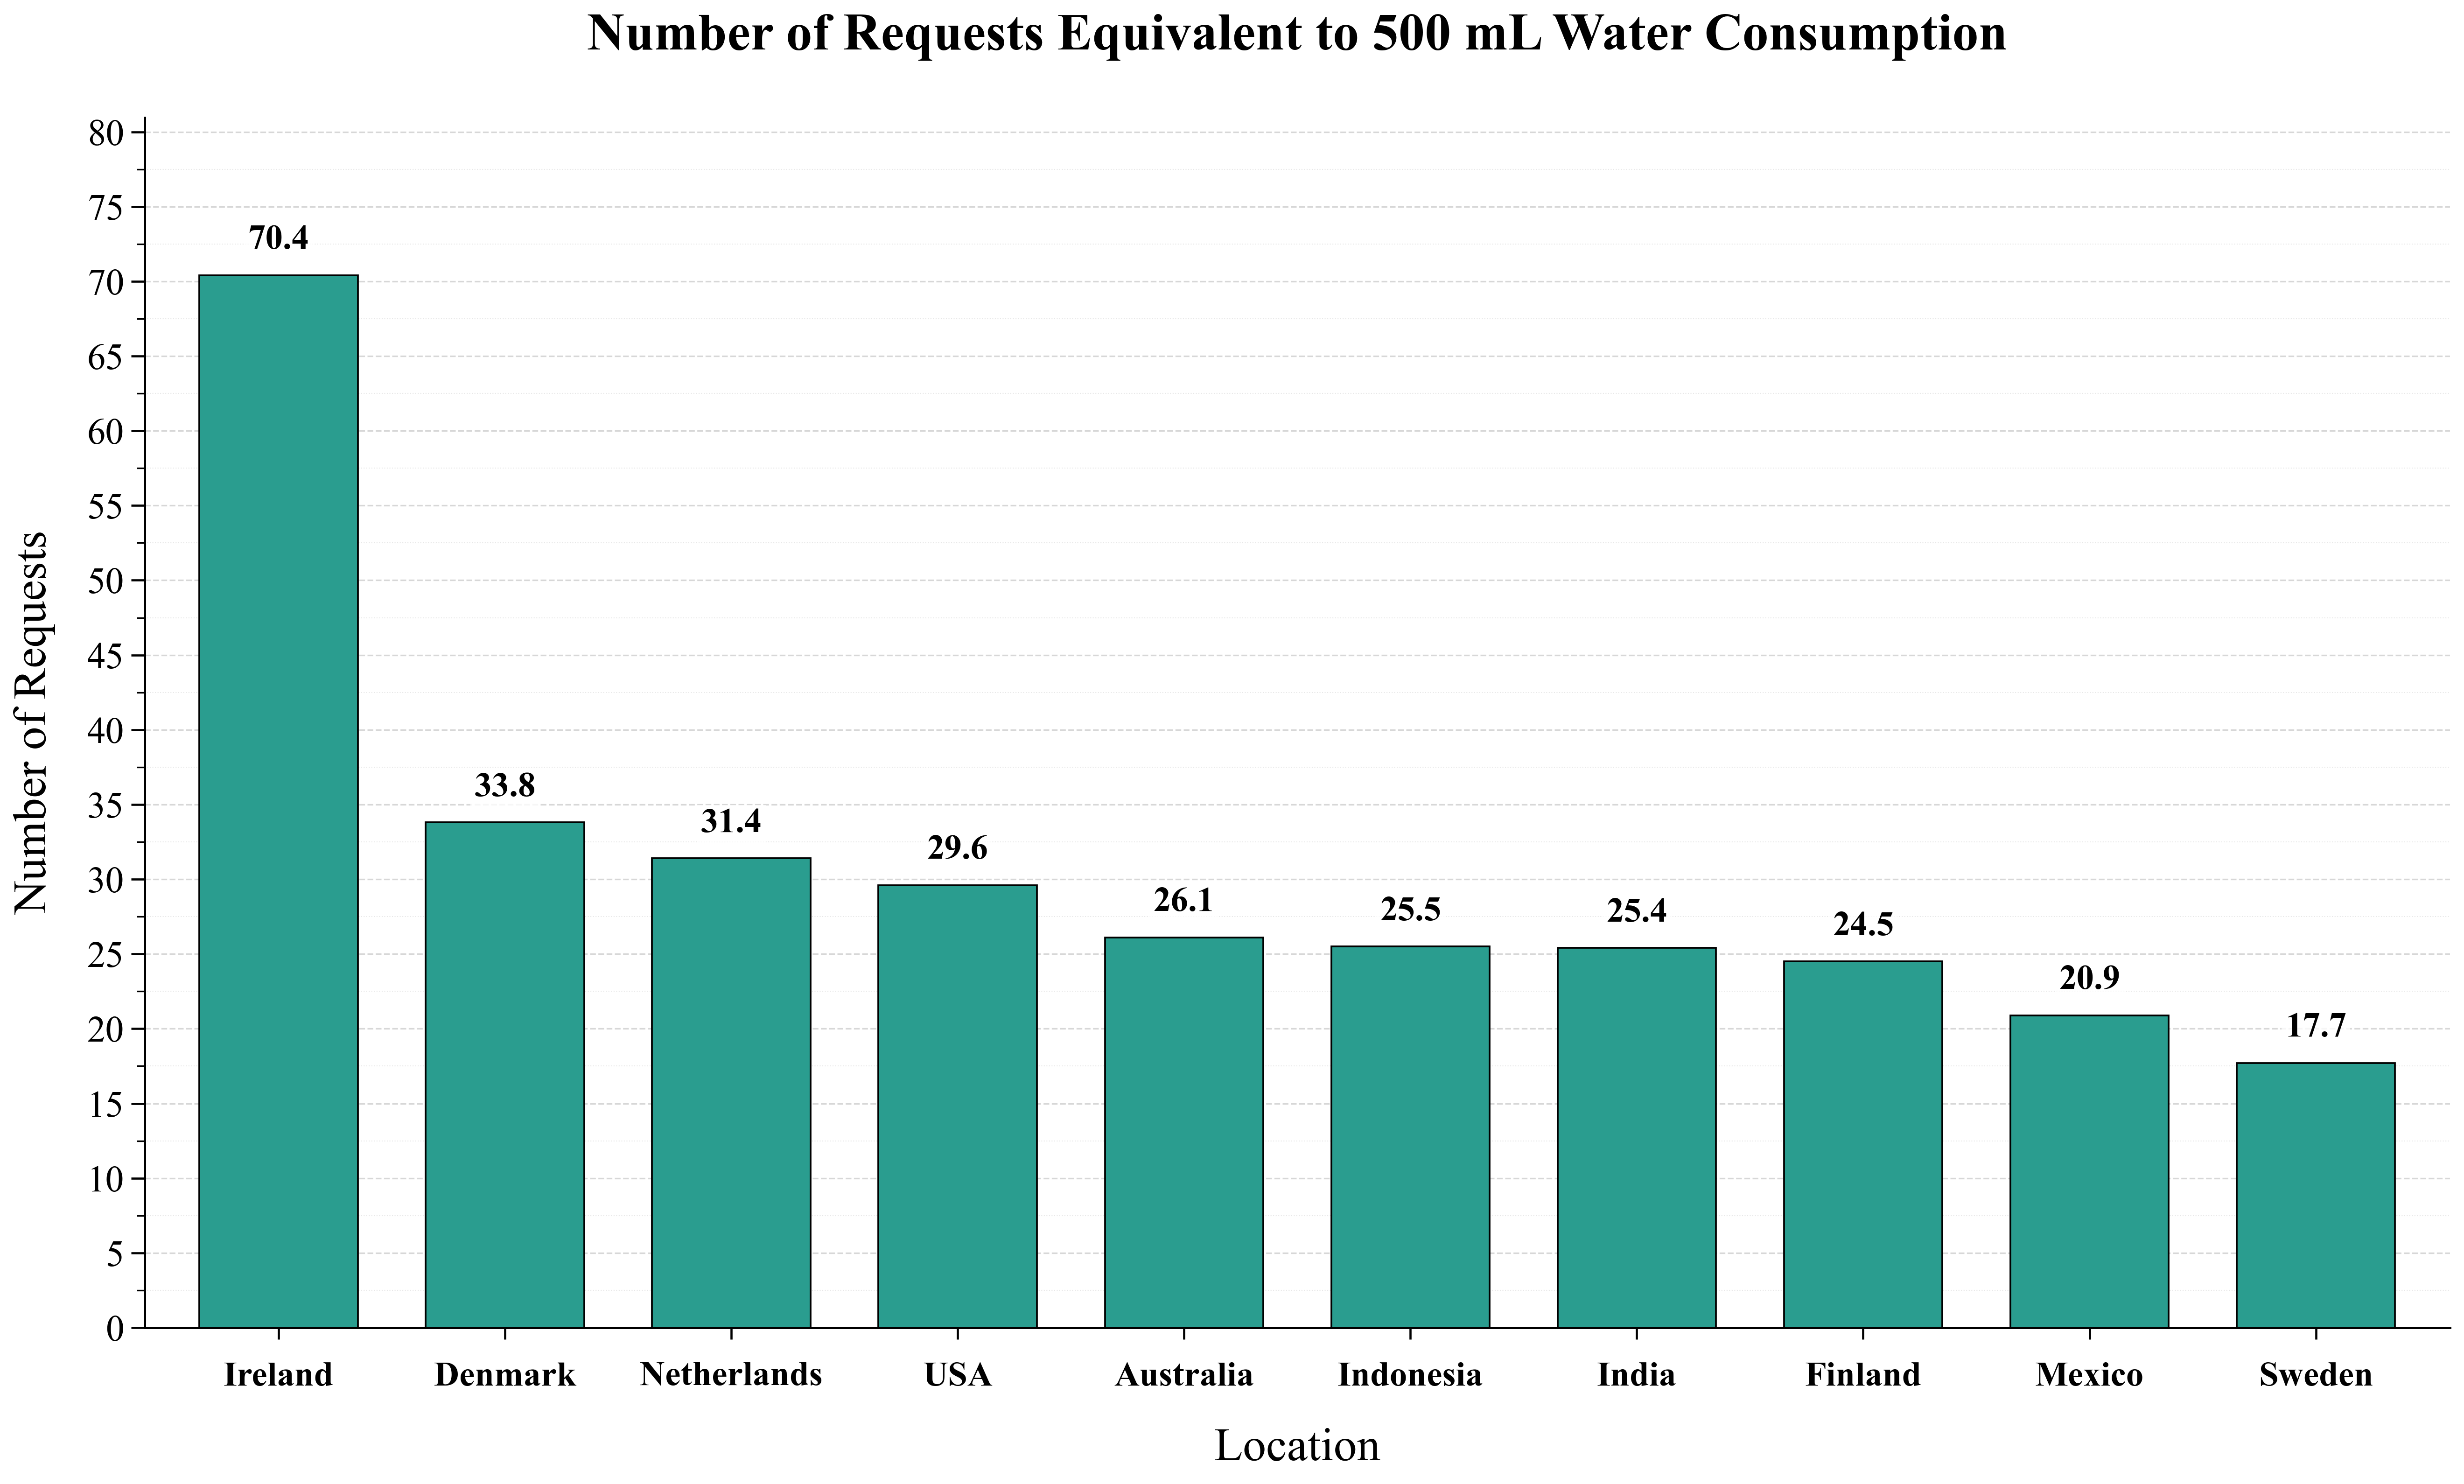

Files saved successfully:
requests_equivalent_to_500ml_transparent.svg
requests_equivalent_to_500ml_transparent.pdf
requests_equivalent_to_500ml_transparent.png


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MultipleLocator

# -----------------------------
# Data
# -----------------------------
data = {
    "Location": [
        "USA", "Australia", "Denmark", "Finland", "India",
        "Indonesia", "Ireland", "Mexico", "Netherlands", "Sweden"
    ],
    "Number of Requests": [
        29.6, 26.1, 33.8, 24.5, 25.4,
        25.5, 70.4, 20.9, 31.4, 17.7
    ]
}

df = pd.DataFrame(data)

# Sort locations by number of requests
df = df.sort_values(
    "Number of Requests",
    ascending=False
).reset_index(drop=True)

# -----------------------------
# Larger journal-style formatting
# -----------------------------
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 20
plt.rcParams["axes.labelsize"] = 24
plt.rcParams["axes.titlesize"] = 27
plt.rcParams["xtick.labelsize"] = 18
plt.rcParams["ytick.labelsize"] = 19
plt.rcParams["figure.dpi"] = 300
plt.rcParams["axes.linewidth"] = 1.2

# -----------------------------
# Plot setup
# -----------------------------
x = np.arange(len(df["Location"]))

# Wider figure so straight country names have enough room
fig, ax = plt.subplots(figsize=(18, 11))

# Transparent background
fig.patch.set_alpha(0)
ax.patch.set_alpha(0)

# -----------------------------
# Vertical bars
# -----------------------------
bars = ax.bar(
    x,
    df["Number of Requests"],
    width=0.70,
    color="#2A9D8F",
    edgecolor="black",
    linewidth=0.9
)

# -----------------------------
# Axes, labels and title
# -----------------------------
ax.set_xticks(x)

# Keep country names completely straight
ax.set_xticklabels(
    df["Location"],
    rotation=0,
    ha="center",
    fontsize=18,
    fontweight="semibold"
)

ax.set_xlabel(
    "Location",
    labelpad=18,
    fontsize=24,
    fontweight="normal"
)

ax.set_ylabel(
    "Number of Requests",
    labelpad=16,
    fontsize=24,
    fontweight="normal"
)

ax.set_title(
    "Number of Requests Equivalent to 500 mL Water Consumption",
    pad=35,
    fontsize=27,
    fontweight="bold"
)

# -----------------------------
# Y-axis scale points
# -----------------------------
ax.yaxis.set_major_locator(MultipleLocator(5))
ax.yaxis.set_minor_locator(MultipleLocator(2.5))

# Major gridlines
ax.grid(
    axis="y",
    which="major",
    linestyle="--",
    linewidth=0.8,
    alpha=0.50
)

# Minor gridlines
ax.grid(
    axis="y",
    which="minor",
    linestyle=":",
    linewidth=0.5,
    alpha=0.30
)

ax.tick_params(
    axis="y",
    which="major",
    length=7,
    width=1.1,
    labelsize=19
)

ax.tick_params(
    axis="y",
    which="minor",
    length=4,
    width=0.8
)

ax.tick_params(
    axis="x",
    which="major",
    length=6,
    width=1.1,
    pad=12
)

ax.set_axisbelow(True)

# -----------------------------
# Larger value labels above bars
# -----------------------------
max_value = df["Number of Requests"].max()
label_offset = max_value * 0.018

for bar, value in zip(bars, df["Number of Requests"]):
    bar_height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar_height + label_offset,
        f"{value:.1f}",
        ha="center",
        va="bottom",
        fontsize=18,
        fontweight="bold",
        color="black",
        clip_on=False,
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.80,
            pad=2
        )
    )

# -----------------------------
# Borders and limits
# -----------------------------
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)

ax.set_ylim(0, max_value * 1.15)
ax.margins(x=0.025)

plt.tight_layout()

# -----------------------------
# Output filenames
# -----------------------------
output_svg = "requests_equivalent_to_500ml_transparent.svg"
output_pdf = "requests_equivalent_to_500ml_transparent.pdf"
output_png = "requests_equivalent_to_500ml_transparent.png"

# -----------------------------
# Save transparent lossless files
# -----------------------------
fig.savefig(
    output_svg,
    format="svg",
    transparent=True,
    bbox_inches="tight",
    facecolor="none",
    edgecolor="none"
)

fig.savefig(
    output_pdf,
    format="pdf",
    transparent=True,
    bbox_inches="tight",
    facecolor="none",
    edgecolor="none"
)

fig.savefig(
    output_png,
    format="png",
    dpi=600,
    transparent=True,
    bbox_inches="tight",
    facecolor="none",
    edgecolor="none"
)

plt.show()

# -----------------------------
# Download files in Google Colab
# -----------------------------
try:
    from google.colab import files

    files.download(output_svg)
    files.download(output_pdf)
    files.download(output_png)

except ImportError:
    print("Files saved successfully:")
    print(output_svg)
    print(output_pdf)
    print(output_png)